# 4주차 복습과제 _ 최지희
## Deep Q-Learning
 : 합성곱 신경망을 이용하여 큐 함수 학습
 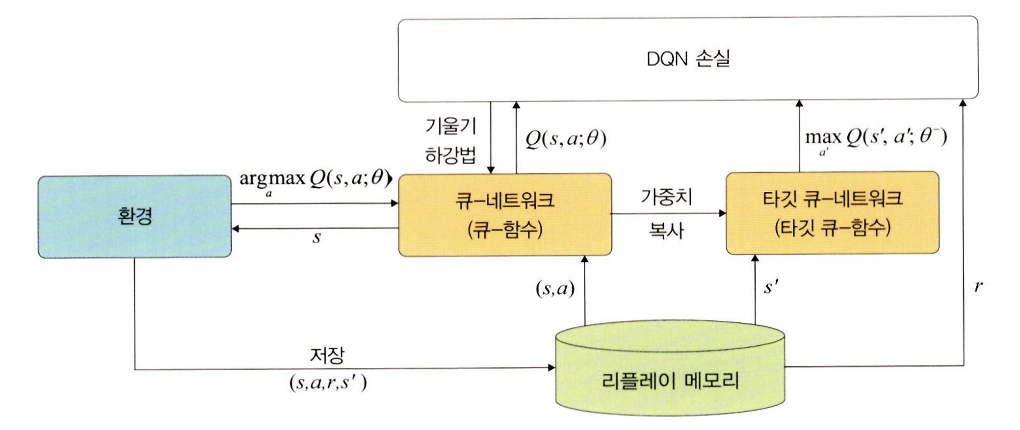
 

In [1]:
!pip install gym

- gym 패키지 : 강화 학습 환경 구성

In [2]:
#라이브러리 호출
import gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple  #튜플에 담긴 요소들의 인덱스와 값으로 모두 접근 가능
from itertools import count  #무한 루프 사용을 위한 라이브러리
from PIL import Image  #이미지 처리를 위한 라이브러리

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

# Gym 0.26+ 에서는 render_mode를 환경 생성 시 지정해야 rgb 프레임을 얻을 수 있음
env = gym.make('CartPole-v1', render_mode='rgb_array').unwrapped  #cartpole이라는 강화 학습 환경을 불러옴
plt.ion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
#한글 깨짐 방지 코드
from matplotlib import font_manager, rc

font_path = './malgun.ttf'
font_manager.fontManager.addfont(font_path)
font_family = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_family
plt.rcParams['axes.unicode_minus'] = False

In [4]:
#리플레이 메모리
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))  #(1)

class ReplayMemory(object):  #(2)
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [5]:
#DQN 모델 네트워크
class DQN(nn.Module):
    def __init__(self, h, w, outputs):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)

        def conv2d_size_out(size, kernel_size=5, stride=2):
            return(size - (kernel_size-1)-1) // stride + 1

        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
        linear_input_size = convw * convh * 32  #(1)
        self.head = nn.Linear(linear_input_size, outputs)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return self.head(x.view(x.size(0), -1))  #함수의 반환값은 [[left0exp,right0exp]...]와 같으며 다음 행동을 결정하기 위해 사용

In [6]:
!pip install pyglet

/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


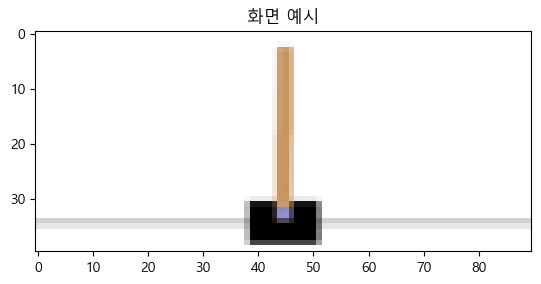

In [7]:
#이미지 추출 및 처리
import pyglet

resize = T.Compose([T.ToPILImage(),
                    T.Resize(40, interpolation=Image.Resampling.BICUBIC),
                    T.ToTensor()])  #이미지 크기 및 텐서 변환

def get_cart_location(screen_width):  #카트의 위치 정보 가져오기
    world_width = env.x_threshold * 2
    scale = screen_width / world_width
    return int(env.state[0] * scale + screen_width / 2.0)  #카드의 중간(중앙) 위치

def get_screen():  #(1)
    screen = env.render().transpose((2, 0, 1))  #(2)
    _, screen_height, screen_width = screen.shape
    screen = screen[:, int(screen_height*0.4):int(screen_height * 0.8)]
    view_width = int(screen_width * 0.6)
    cart_location = get_cart_location(screen_width)

    if cart_location < view_width // 2:  #카트는 출력 화면의 아래쪽 중앙에 존재하므로 화면의 위쪽과 아래쪽을 제거
        slice_range = slice(view_width)  #(3)
    elif cart_location > (screen_width - view_width // 2):
        slice_range = slice(-view_width, None)
    else:
        slice_range = slice(cart_location - view_width // 2,
                            cart_location + view_width // 2)
    screen = screen[:, :, slice_range]  #카트가 화면의 중앙에 위치하도록 가장자리를 제거
    screen = np.ascontiguousarray(screen, dtype=np.float32) / 255  #(4)
    screen = torch.from_numpy(screen)  #텐서로 변환
    return resize(screen).unsqueeze(0).to(device)  #출력 크기 조정 및 배치 차원 추가하여 데이터는 (배치, 채널, 높이, 너비)의 평태를 가짐

env.reset()  #환경을 초기화
plt.figure()
plt.imshow(get_screen().cpu().squeeze(0).permute(1, 2, 0).numpy(),
           interpolation='none')  #permute 함수는 transpose 함수처럼 차원을 바꾸어서 표현할 때 사용
plt.title('화면 예시')
plt.show()

In [8]:
import torch.optim as optim
#모델 객체화 및 손실 함수 정의
BATCH_SIZE = 128
GAMMA = 0.999
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY =200
TARGET_UPDATE = 10

init_screen = get_screen()  #(1)
_, _, screen_height, screen_width = init_screen.shape
n_actions = env.action_space.n  #gym에서 행동(action)에 대한 횟수를 가져옴

policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())  #(2)
target_net.eval()

optimizer = optim.RMSprop(policy_net.parameters())
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)  #max(1)은 각 행의 가장 큰 열 값을 반환
    else:
        return torch.tensor([[random.randrange(n_actions)]], device=device,
                            dtype=torch.long)

episode_durations = []

In [9]:
#모델에서 사용할 옵티마이저 정의
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))  #(1)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                            batch.next_state)), device=device, dtype=torch.bool)  #(2)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                       if s is not None])  #torch.cat을 이용하여 s 값들을 이어 붙임
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)  #Q(s_t, a_t)를 계산
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()  #(3)

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch  #V(s_{t+1})을 계산

    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))  #(4)
    optimizer.zero_grad()
    loss.backward()

    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()


In [10]:
#모델 학습
num_episodes = 50

for i_episode in range(num_episodes):
    env.reset()  #환경과 상태 초기화
    last_screen = get_screen()
    current_screen = get_screen()
    state = current_screen - last_screen

    for t in count():
        action = select_action(state)  #행동 선택 및 실행
        next_state, reward, done, _, _ = env.step(action.item())  #선택한 행동(action)을 환경으로 보냄
        reward = torch.tensor([reward], device=device)

        last_screen = current_screen
        current_screen = get_screen()

        if not done:  #새로운 상태 관찰(observe)
            next_state = current_screen - last_screen
        else:
            next_state = None

        memory.push(state, action, next_state, reward)  #상태 전이(state transition)를 메모리에 저장
        state = next_state  #다음 상태로 이동

        optimize_model()  #타깃(큐)네트워크에 대해 최적화 진행
        if done:
            episode_durations.append(t + 1)
            break

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())  #큐 네트워크의 모든 가중치와 바이어스를 복사해 타킷(큐) 네트워크를 업데이트

print('종료')
env.render()  #화면을 출력
env.close()  #화면을 종료
plt.show()

종료
